In [1]:
# Installa yfinance se non è presente nell'ambiente
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configurazione estetica dei grafici
plt.style.use('seaborn-v0_8' if 'seaborn-v0_8' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)

print("Librerie importate con successo!")

Librerie importate con successo!


In [4]:
tickers = ['AAPL', 'MSFT', 'JNJ', 'XOM', 'JPM', 'PG']
start_date = '2019-01-01'
end_date = '2024-01-01'

# Download dei dati disattivando l'aggiustamento automatico
print("Scaricamento dati in corso...")
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)['Adj Close']

# Mostra le prime 5 righe del dataset
display(data.head())

[*********************100%***********************]  6 of 6 completed

Scaricamento dati in corso...


Ticker,AAPL,JNJ,JPM,MSFT,PG,XOM
Date,,,,,,
2019-01-02,37.436920,103.281593,80.473999,94.016136,74.789925,49.345230
2019-01-03,33.707935,101.640411,79.330299,90.557480,74.265556,48.587601
2019-01-04,35.146893,103.346268,82.254860,94.769249,75.781349,50.379009
2019-01-07,35.068649,102.683357,82.312050,94.890099,75.478195,50.640991
2019-01-08,35.737171,105.068314,82.156822,95.578140,75.756798,51.009182


In [5]:
# Calcolo dei rendimenti giornalieri
daily_returns = data.pct_change().dropna()

# Creazione Portafoglio Equal-Weighted (Equipensato)
# np.ones(6) / 6 crea un array con pesi [0.166, 0.166, ...]
weights = np.ones(len(tickers)) / len(tickers)

# Moltiplica i rendimenti per i pesi
daily_returns['Portfolio_EW'] = daily_returns.dot(weights)

print("Rendimenti calcolati! Ultime 5 righe:")
display(daily_returns.tail())

Rendimenti calcolati! Ultime 5 righe:


Ticker,AAPL,JNJ,JPM,MSFT,PG,XOM,Portfolio_EW
Date,,,,,,,
2023-12-22,-0.005547,0.004004,-0.000597,0.002784,0.007070,0.001769,0.001581
2023-12-26,-0.002841,0.004374,0.005914,0.000214,0.004543,0.002257,0.002410
2023-12-27,0.000518,0.001345,0.005998,-0.001575,0.000822,-0.004699,0.000402
2023-12-28,0.002226,0.001471,0.005313,0.003235,-0.002259,-0.014460,-0.000746
2023-12-29,-0.005424,0.001022,-0.001174,0.002025,0.005558,-0.002096,-0.000015


In [6]:
risk_free_rate = 0.03  # Tasso free-risk stimato al 3%

def calculate_metrics(returns_series, rf=0.03):
    # Annualizzazione (assumendo 252 giorni di trading in un anno)
    ann_return = returns_series.mean() * 252
    ann_volatility = returns_series.std() * np.sqrt(252)

    # Sharpe Ratio: Rendimento extra per unità di rischio
    sharpe_ratio = (ann_return - rf) / ann_volatility

    # Maximum Drawdown: Peggior crollo dal picco massimo
    cum_returns = (1 + returns_series).cumprod()
    peak = cum_returns.cummax()
    drawdown = (cum_returns - peak) / peak
    max_drawdown = drawdown.min()

    return {
        'Rendimento Ann. (%)': ann_return * 100,
        'Volatilità Ann. (%)': ann_volatility * 100,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown (%)': max_drawdown * 100
    }

# Applica la funzione a ogni colonna (titoli + portafoglio)
metrics_df = pd.DataFrame([calculate_metrics(daily_returns[col], rf=risk_free_rate)
                           for col in daily_returns.columns],
                          index=daily_returns.columns)

print("=== METRICHE DI RISCHIO E PERFORMANCE ===")
display(metrics_df.round(2))

=== METRICHE DI RISCHIO E PERFORMANCE ===


,Rendimento Ann. (%),Volatilità Ann. (%),Sharpe Ratio,Max Drawdown (%)
Ticker,,,,
AAPL,37.80,32.23,1.08,-31.43
JNJ,8.78,19.86,0.29,-27.37
JPM,18.90,31.90,0.50,-43.63
MSFT,32.03,30.49,0.95,-37.15
PG,14.27,21.16,0.53,-23.77
XOM,18.24,34.28,0.44,-60.35
Portfolio_EW,21.67,20.72,0.90,-33.19


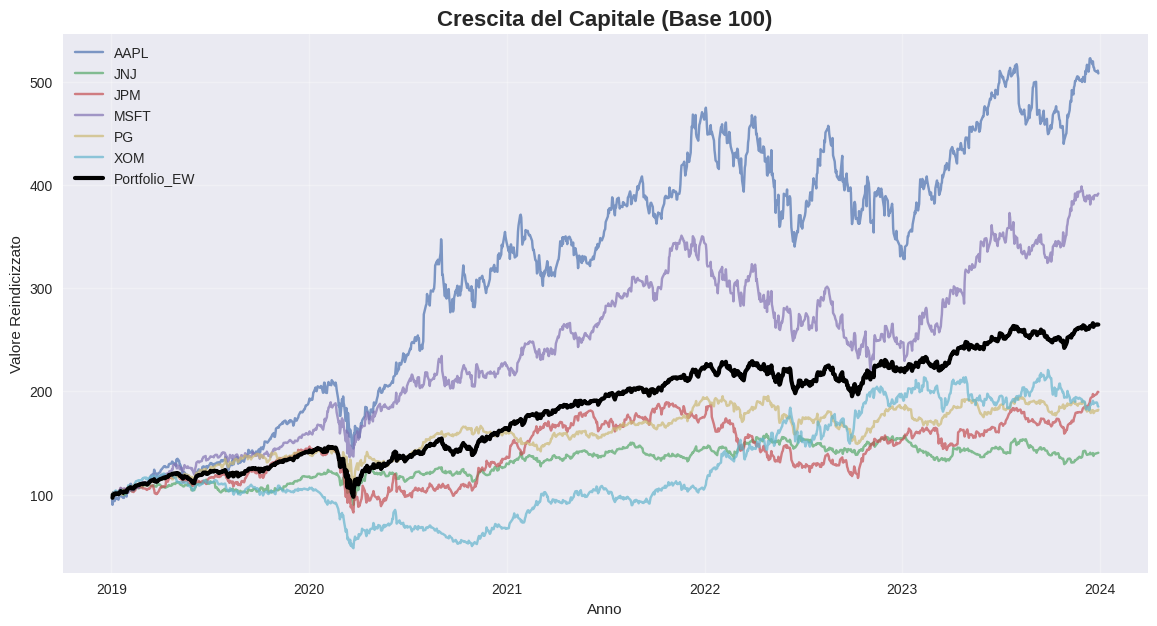

In [7]:
# Normalizza i prezzi: Prezzo odierno / Prezzo giorno 1 * 100
normalized_prices = (data / data.iloc[0]) * 100

plt.figure(figsize=(14, 7))
for col in normalized_prices.columns:
    plt.plot(normalized_prices.index, normalized_prices[col], label=col, alpha=0.7)

# Aggiungiamo anche il grafico del portafoglio (calcolando i prezzi cumulati)
port_cum_returns = (1 + daily_returns['Portfolio_EW']).cumprod() * 100
plt.plot(port_cum_returns.index, port_cum_returns,
         label='Portfolio_EW', color='black', linewidth=3)

plt.title('Crescita del Capitale (Base 100)', fontsize=16, fontweight='bold')
plt.xlabel('Anno')
plt.ylabel('Valore Reindicizzato')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# 1. Prepariamo i dati (escludiamo il Portfolio_EW della Fase 1)
assets_returns = daily_returns.drop(columns=['Portfolio_EW'])

# Rendimenti medi annualizzati e Matrice di Covarianza
mean_returns = assets_returns.mean() * 252
cov_matrix = assets_returns.cov() * 252

# 2. Impostazioni della simulazione
num_portfolios = 10000
results = np.zeros((3, num_portfolios))
weights_record = []

print("Avvio simulazione Monte Carlo su 10.000 portafogli...")

for i in range(num_portfolios):
    # Genera pesi casuali e normalizzali a 1 (100%)
    weights = np.random.random(len(mean_returns))
    weights /= np.sum(weights)
    weights_record.append(weights)

    # Calcola Rendimento e Volatilità del portafoglio
    portfolio_return = np.sum(mean_returns * weights)
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    # Registra i risultati: [0] Volatilità, [1] Rendimento, [2] Sharpe Ratio
    results[0, i] = portfolio_std_dev
    results[1, i] = portfolio_return
    results[2, i] = (portfolio_return - risk_free_rate) / portfolio_std_dev

print("Simulazione completata!")

Avvio simulazione Monte Carlo su 10.000 portafogli...
Simulazione completata!



=== ALLOCAZIONE OTTIMALE DEL CAPITALE ===


,Max Sharpe Portfolio (%),Min Volatility Portfolio (%)
Ticker,,
AAPL,55.83,0.31
JNJ,3.11,36.17
JPM,2.64,0.15
MSFT,24.06,2.63
PG,12.03,42.88
XOM,2.32,17.86


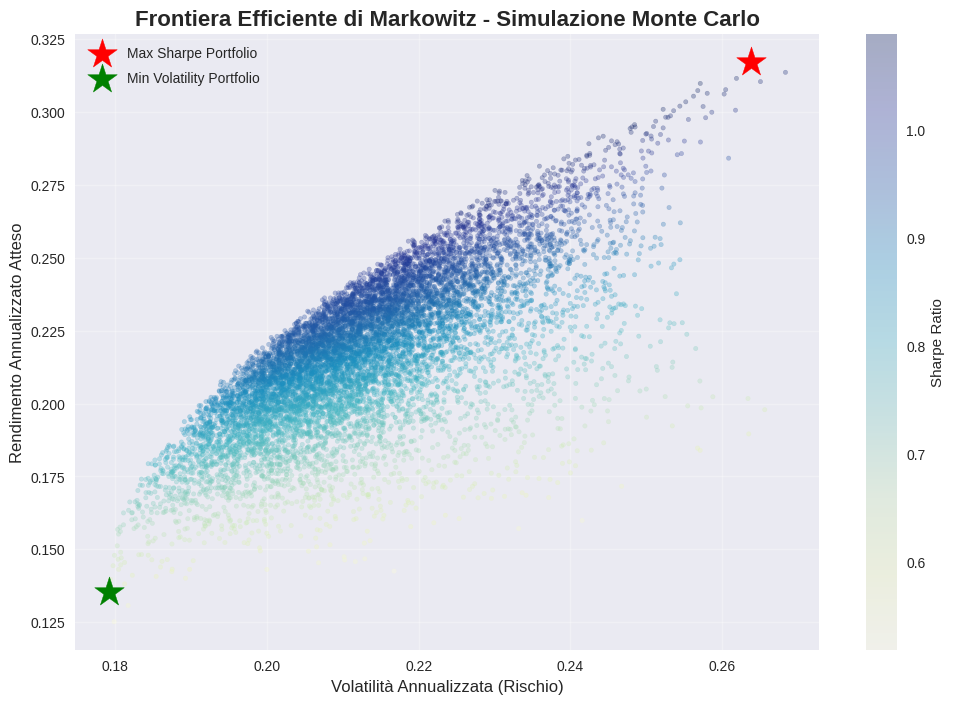

In [9]:
# 3. Identifica i portafogli ottimali
# Indice del Max Sharpe Ratio
max_sharpe_idx = np.argmax(results[2])
sdp_max, rp_max = results[0, max_sharpe_idx], results[1, max_sharpe_idx]

# Indice della Minima Varianza (Rischio Minimo)
min_vol_idx = np.argmin(results[0])
sdp_min, rp_min = results[0, min_vol_idx], results[1, min_vol_idx]

# 4. Crea i DataFrame per stampare i pesi ottimali in modo leggibile
opt_weights = pd.DataFrame({
    'Max Sharpe Portfolio (%)': np.array(weights_record[max_sharpe_idx]) * 100,
    'Min Volatility Portfolio (%)': np.array(weights_record[min_vol_idx]) * 100
}, index=assets_returns.columns)

print("\n=== ALLOCAZIONE OTTIMALE DEL CAPITALE ===")
display(opt_weights.round(2))

# 5. Visualizzazione della Frontiera Efficiente
plt.figure(figsize=(12, 8))
# Scatter plot di tutti i portafogli, colorati in base allo Sharpe Ratio
scatter = plt.scatter(results[0,:], results[1,:], c=results[2,:],
                      cmap='YlGnBu', marker='o', s=10, alpha=0.3)
plt.colorbar(scatter, label='Sharpe Ratio')

# Evidenzia il portafoglio Max Sharpe (Stella Rossa)
plt.scatter(sdp_max, rp_max, marker='*', color='r', s=500, label='Max Sharpe Portfolio')
# Evidenzia il portafoglio a Minima Varianza (Stella Verde)
plt.scatter(sdp_min, rp_min, marker='*', color='g', s=500, label='Min Volatility Portfolio')

plt.title('Frontiera Efficiente di Markowitz - Simulazione Monte Carlo', fontsize=16, fontweight='bold')
plt.xlabel('Volatilità Annualizzata (Rischio)', fontsize=12)
plt.ylabel('Rendimento Annualizzato Atteso', fontsize=12)
plt.legend(labelspacing=0.8)
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# 1. Ricostruiamo i rendimenti storici giornalieri dei nostri due portafogli ideali
# Pesi ottimali trovati nello step precedente
weights_max_sharpe = weights_record[max_sharpe_idx]
weights_min_vol = weights_record[min_vol_idx]

# Moltiplichiamo i rendimenti dei singoli asset per i pesi
returns_max_sharpe = assets_returns.dot(weights_max_sharpe)
returns_min_vol = assets_returns.dot(weights_min_vol)

# 2. Funzione per calcolare VaR e CVaR Storico
def calculate_var_cvar(returns, confidence_level=0.95):
    # Il VaR è il percentile della distribuzione dei rendimenti
    alpha = 1 - confidence_level
    var = np.percentile(returns, alpha * 100)

    # Il CVaR è la media di tutti i rendimenti che sono peggiori del VaR
    cvar = returns[returns <= var].mean()

    # Moltiplichiamo per 100 per avere la percentuale
    return var * 100, cvar * 100

# 3. Calcolo al 95% e 99% per il portafoglio Max Sharpe
var_95_ms, cvar_95_ms = calculate_var_cvar(returns_max_sharpe, 0.95)
var_99_ms, cvar_99_ms = calculate_var_cvar(returns_max_sharpe, 0.99)

# 4. Calcolo al 95% e 99% per il portafoglio Min Volatility
var_95_mv, cvar_95_mv = calculate_var_cvar(returns_min_vol, 0.95)
var_99_mv, cvar_99_mv = calculate_var_cvar(returns_min_vol, 0.99)

# 5. Stampa dei risultati
print("=== ANALISI DEI RISCHI ESTREMI (GIORNALIERI) ===")
print("\n[Portafoglio Max Sharpe]")
print(f"VaR 95%:  {var_95_ms:.2f}% (Nel 95% dei giorni, la perdita non supererà questo valore)")
print(f"CVaR 95%: {cvar_95_ms:.2f}% (Se c'è un crollo che supera il VaR, questa è la perdita media attesa)")
print(f"VaR 99%:  {var_99_ms:.2f}%")
print(f"CVaR 99%: {cvar_99_ms:.2f}%")

print("\n[Portafoglio Min Volatility]")
print(f"VaR 95%:  {var_95_mv:.2f}%")
print(f"CVaR 95%: {cvar_95_mv:.2f}%")
print(f"VaR 99%:  {var_99_mv:.2f}%")
print(f"CVaR 99%: {cvar_99_mv:.2f}%")

=== ANALISI DEI RISCHI ESTREMI (GIORNALIERI) ===

[Portafoglio Max Sharpe]
VaR 95%:  -2.40% (Nel 95% dei giorni, la perdita non supererà questo valore)
CVaR 95%: -3.81% (Se c'è un crollo che supera il VaR, questa è la perdita media attesa)
VaR 99%:  -4.39%
CVaR 99%: -6.41%

[Portafoglio Min Volatility]
VaR 95%:  -1.57%
CVaR 95%: -2.60%
VaR 99%:  -2.66%
CVaR 99%: -4.91%
